In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import plotly.express as px

In [2]:
pd.set_option("display.max_columns", 500)

In [3]:
sns.set_style("whitegrid")
sns.set_theme("notebook")

In [4]:
df = pd.read_csv("PS_20174392719_1491204439457_log.csv"
                 )

In [5]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [6]:
df.shape


(6362620, 11)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 706.2 MB


In [8]:
df.describe().round()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6362620.0,6362620.0,6362620.0,6362620.0,6362620.0,6362620.0,6362620.0,6362620.0
mean,243.0,179862.0,833883.0,855114.0,1100702.0,1224996.0,0.0,0.0
std,142.0,603858.0,2888243.0,2924049.0,3399180.0,3674129.0,0.0,0.0
min,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,156.0,13390.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,239.0,74872.0,14208.0,0.0,132706.0,214661.0,0.0,0.0
75%,335.0,208721.0,107315.0,144258.0,943037.0,1111909.0,0.0,0.0
max,743.0,92445517.0,59585040.0,49585040.0,356015889.0,356179279.0,1.0,1.0


In [9]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [10]:
df["isFraud"].value_counts(normalize=True)

isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64

In [11]:
df.columns.tolist()

['step',
 'type',
 'amount',
 'nameOrig',
 'oldbalanceOrg',
 'newbalanceOrig',
 'nameDest',
 'oldbalanceDest',
 'newbalanceDest',
 'isFraud',
 'isFlaggedFraud']

In [12]:
df.columns = df.columns.str.strip()

In [13]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [14]:
df[df.amount < 0].value_counts()

Series([], Name: count, dtype: int64)

In [15]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
# Checking the customers and merchants
df["nameOrig"].str[:1].unique()

<ArrowStringArray>
['C']
Length: 1, dtype: str

In [18]:
df["nameDest"].str[:1].value_counts(normalize=True)

nameDest
C    0.661854
M    0.338146
Name: proportion, dtype: float64

In [19]:
print({"Flagged Fraud" : df["isFlaggedFraud"].value_counts(),
       "Actual Fraud" : df["isFraud"].value_counts()})

{'Flagged Fraud': isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64, 'Actual Fraud': isFraud
0    6354407
1       8213
Name: count, dtype: int64}


In [20]:
# EDA for Type Analysis

df.groupby("type")["isFraud"].value_counts().reset_index()

,type,isFraud,count
0,CASH_IN,0,1399284
1,CASH_OUT,0,2233384
2,CASH_OUT,1,4116
3,DEBIT,0,41432
4,PAYMENT,0,2151495
5,TRANSFER,0,528812
6,TRANSFER,1,4097


Frauds Only detected in CashOut and Transfer Method

In [21]:
frauds_by_type = df.groupby("type")["isFraud"].sum().reset_index()

In [22]:
frauds_by_type

,type,isFraud
0,CASH_IN,0
1,CASH_OUT,4116
2,DEBIT,0
3,PAYMENT,0
4,TRANSFER,4097


In [23]:
frauds_by_type.reset_index()

,index,type,isFraud
0,0,CASH_IN,0
1,1,CASH_OUT,4116
2,2,DEBIT,0
3,3,PAYMENT,0
4,4,TRANSFER,4097


Text(0.5, 1.0, 'Frauds By Type')

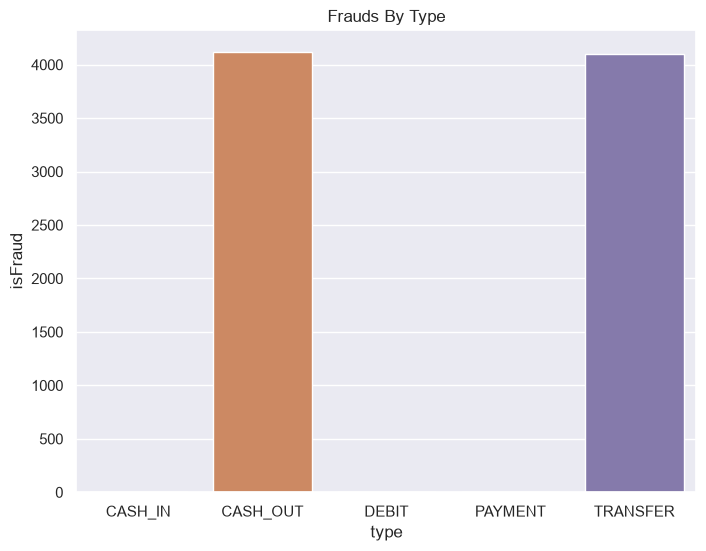

In [24]:
plt.figure(figsize = (8,6))
sns.barplot(data = frauds_by_type, x="type", y="isFraud", hue = "type")
plt.title("Frauds By Type")

In [25]:
pd.crosstab(df["type"], df["isFraud"], normalize="index")

isFraud,0,1
type,,
CASH_IN,1.000000,0.000000
CASH_OUT,0.998160,0.001840
DEBIT,1.000000,0.000000
PAYMENT,1.000000,0.000000
TRANSFER,0.992312,0.007688


In [26]:
# Transaction amount distribution over type

amounts = df.groupby("type")["amount"].sum().reset_index()

<Figure size 1000x800 with 0 Axes>

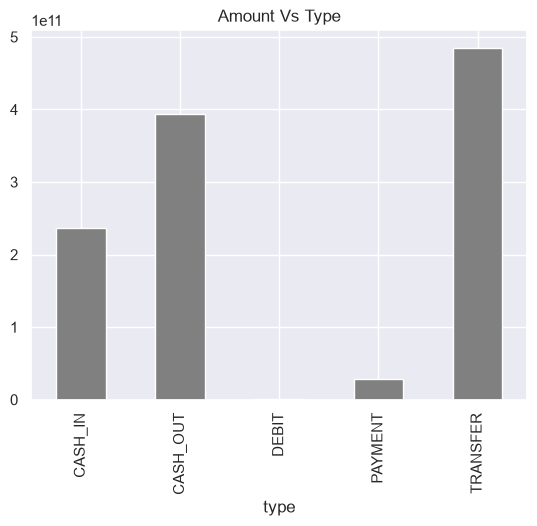

In [27]:
plt.figure(figsize = (10,8))
amounts.plot(
    kind="bar",
    x="type",
    y="amount",
    color = "grey",
    legend=False
)

plt.title("Amount Vs Type")

plt.show()


<Figure size 1000x800 with 0 Axes>

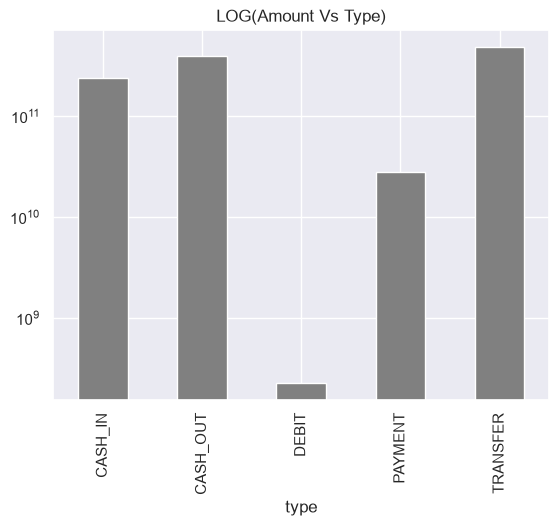

In [28]:
plt.figure(figsize = (10,8))
amounts.plot(
    kind="bar",
    x="type",
    y="amount",
    color = "grey",
    legend=False
)

plt.title("LOG(Amount Vs Type)")
plt.yscale("log")

plt.show()

<Figure size 1200x1000 with 0 Axes>

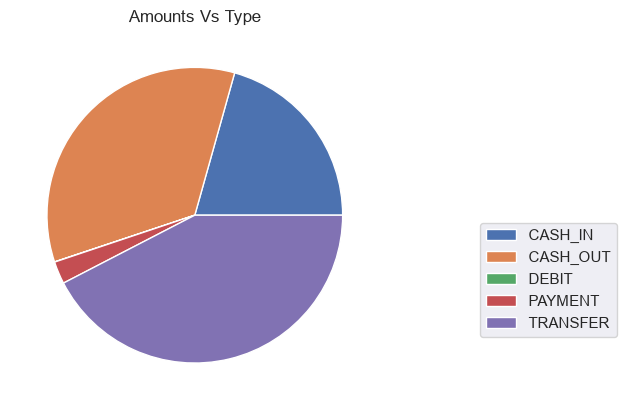

In [29]:

plt.figure(figsize = (12,10))
amounts.plot(
    kind="pie",
    y = "amount",
    color = "grey",
    legend = True,
    labels =None
)
plt.title("Amounts Vs Type")
plt.legend(amounts["type"],bbox_to_anchor=(1.25, 0.5))

plt.show()

In [30]:
#Frauds by Amount

fraud_amounts = df.groupby("isFraud")["amount"].sum().reset_index()

In [31]:
fraud_amounts["isFraud"] = fraud_amounts["isFraud"].map({0 : "Not Fraud", 1 : "Fraud"})

In [32]:
fraud_amounts["Fraud Percent"] = (fraud_amounts["amount"]/fraud_amounts["amount"].sum()) * 100

<Axes: xlabel='isFraud'>

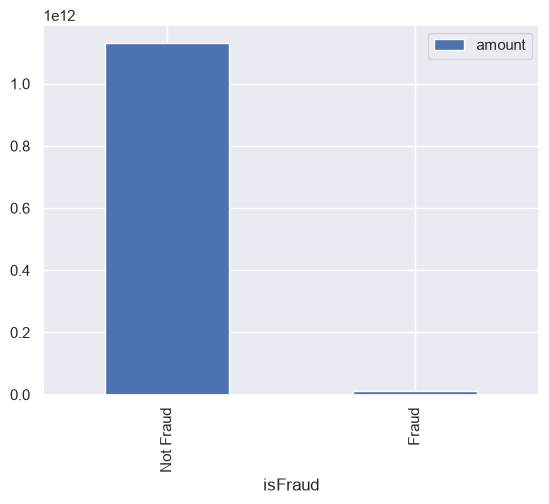

In [33]:
fraud_amounts.plot(kind = "bar", x="isFraud", y = "amount")

<Axes: xlabel='isFraud'>

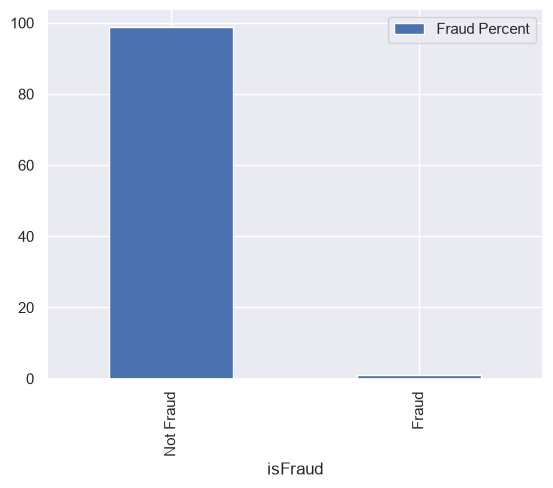

In [34]:
fraud_amounts.plot(kind = "bar", x="isFraud", y = "Fraud Percent")

 Frauds always occurs in Cash_Out and Transfers because most of the transactions occur by those means.

In [35]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [36]:
# Destination Type Vs Frauds
df["Desttype"] = df["nameDest"].str[0].astype(str)

In [37]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,Desttype
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,M
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,M
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,C
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,C
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,M


In [38]:
dest_frauds = df.groupby("Desttype")["isFraud"].value_counts().reset_index()
dest_frauds

,Desttype,isFraud,count
0,C,0,4202912
1,C,1,8213
2,M,0,2151495


This shows that frauds occur between C to C Transaction and not C to M transactions.

In [39]:
dest_frauds_count = df.groupby("Desttype")["isFraud"].sum().reset_index()

<Axes: xlabel='Desttype'>

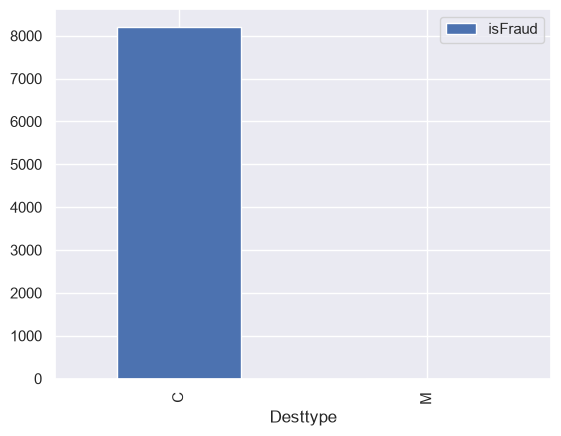

In [40]:
dest_frauds_count.plot(kind = "bar", x="Desttype")

Now we will analyse time dependent factors

In [41]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,Desttype
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,M
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,M
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,C
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,C
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,M


In [42]:
df["hour"] = df["step"] % 24

In [43]:
df["Day"] = df["step"] //24

In [44]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,Desttype,hour,Day
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,M,1,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,M,1,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,C,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,C,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,M,1,0


In [45]:
df.hour.unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23,  0])

In [46]:
frauds_by_hour = df.groupby("hour").agg(Total_Transactions = ("isFraud", "count"), Total_Frauds = ("isFraud", "sum")).reset_index()

In [47]:
frauds_by_hour["Frauds Percent"] = (frauds_by_hour["Total_Frauds"] /frauds_by_hour["Total_Transactions"]) * 100

In [48]:
frauds_by_hour

,hour,Total_Transactions,Total_Frauds,Frauds Percent
0,0,71587,300,0.419071
1,1,27111,358,1.320497
2,2,9018,372,4.125083
3,3,2007,326,16.243149
4,4,1241,274,22.078969
5,5,1641,366,22.303473
6,6,3420,358,10.467836
7,7,8988,328,3.649310
8,8,26915,368,1.367267
9,9,283518,341,0.120275


In [49]:
plt.figure(figsize=(10,8))
px.bar(frauds_by_hour, x = "hour", y="Frauds Percent")


<Figure size 1000x800 with 0 Axes>

In [50]:
px.line(frauds_by_hour, x = "hour", y="Frauds Percent", markers="o" )

Maximum Frauds occur in Midnight from 2 to 6 in the morning

In [51]:
df["Day"].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30])

In [52]:
frauds_by_day = df.groupby("Day").agg(Total_Transactions = ("isFraud", "count"), Total_Frauds = ("isFraud", "sum")).reset_index()

In [53]:
frauds_by_day["Frauds Percent"] = (frauds_by_day["Total_Frauds"] /frauds_by_day["Total_Transactions"]) * 100

In [54]:
frauds_by_day["Day_Type"] = np.where(
    frauds_by_day["Day"] % 7 >= 5,
    "Weekend",
    "Weekday"
)

In [55]:
weekend_frauds = frauds_by_day.groupby("Day_Type")["Total_Frauds"].sum().reset_index()

In [56]:
weekend_frauds

,Day_Type,Total_Frauds
0,Weekday,6177
1,Weekend,2036


<Axes: xlabel='Day_Type'>

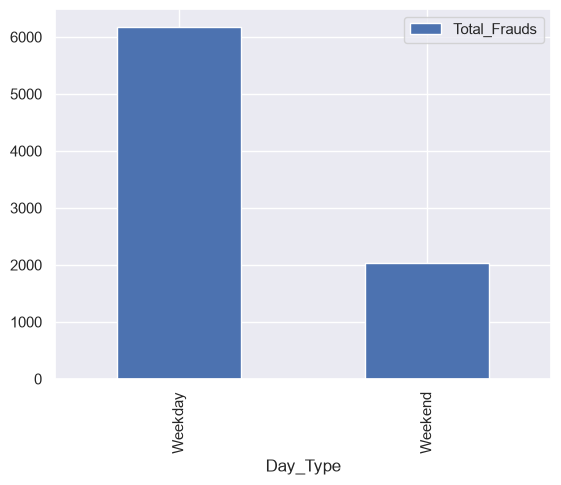

In [57]:
weekend_frauds.plot(kind="bar", x="Day_Type", y = "Total_Frauds")

In [58]:
days = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}

frauds_by_day["Day_Name"] = frauds_by_day["Day"].apply(lambda x: days[x % 7])

In [59]:
Weekday_frauds = frauds_by_day.groupby("Day_Name")["Total_Frauds"].sum().reset_index()

In [60]:
Weekday_frauds

,Day_Name,Total_Frauds
0,Friday,1062
1,Monday,1309
2,Saturday,996
3,Sunday,1040
4,Thursday,1050
5,Tuesday,1302
6,Wednesday,1454


In [61]:
Weekday_frauds["Day_Name"] = Weekday_frauds["Day_Name"].astype(str).str.strip()

In [62]:
Weekday_frauds

,Day_Name,Total_Frauds
0,Friday,1062
1,Monday,1309
2,Saturday,996
3,Sunday,1040
4,Thursday,1050
5,Tuesday,1302
6,Wednesday,1454


In [63]:
dayname = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

In [64]:
Weekday_frauds["Day_Name"] = pd.Categorical(Weekday_frauds["Day_Name"], categories=dayname, ordered=True)
Weekday_frauds = Weekday_frauds.sort_values("Day_Name")

In [65]:
Weekday_frauds

,Day_Name,Total_Frauds
1,Monday,1309
5,Tuesday,1302
6,Wednesday,1454
4,Thursday,1050
0,Friday,1062
2,Saturday,996
3,Sunday,1040


In [66]:
px.line(Weekday_frauds, x = "Day_Name", y = "Total_Frauds", markers=True)

Interesting Monday Tuesday and Wednesday are the most scammed days in the week.

In [67]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,Desttype,hour,Day
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,M,1,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,M,1,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,C,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,C,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,M,1,0


In [68]:
days = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}

df["Day_Name"] = df["Day"].apply(lambda x: days[x % 7])

In [69]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,Desttype,hour,Day,Day_Name
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,M,1,0,Monday
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,M,1,0,Monday
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,C,1,0,Monday
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,C,1,0,Monday
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,M,1,0,Monday


In [71]:
df.to_csv("Frauds.csv")

In [70]:
df["Orginal_balance_diff"] = df["oldbalanceOrg"] - df["newbalanceOrig"]

In [70]:
df["Dest_balance_diff"] = df["oldbalanceDest"] - df["newbalanceDest"]

In [71]:
df["log_amount"] = np.log1p(df["amount"])

In [72]:
df["amount_to_orig_balance"] = (
    df["amount"] / (df["oldbalanceOrg"] + 1)
)
df["amount_to_dest_balance"] = (
    df["amount"] / (df["oldbalanceDest"] + 1)
)

In [73]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,Desttype,hour,Day,Day_Name,Orginal_balance_diff,Dest_balance_diff,log_amount,amount_to_orig_balance,amount_to_dest_balance
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,M,1,0,Monday,9839.64,0.0,9.194276,0.057834,9839.640000
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,M,1,0,Monday,1864.28,0.0,7.531166,0.087731,1864.280000
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,C,1,0,Monday,181.00,0.0,5.204007,0.994505,181.000000
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,C,1,0,Monday,181.00,21182.0,5.204007,0.994505,0.008545
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,M,1,0,Monday,11668.14,0.0,9.364703,0.280788,11668.140000


SOME OF THE OTHER FRAUD KPIs

In [74]:
frauds = df[df['isFraud'] == 1][["isFraud","amount"]].reset_index()

In [75]:
frauds[frauds["amount"] == frauds["amount"].max()]

,index,isFraud,amount
28,4440,1,10000000.0
29,4441,1,10000000.0
227,481250,1,10000000.0
228,481251,1,10000000.0
353,586311,1,10000000.0
...,...,...,...
8172,6362579,1,10000000.0
8173,6362580,1,10000000.0
8174,6362581,1,10000000.0
8175,6362582,1,10000000.0


These are clear frauds

In [76]:
# Avg Fraud Amount
frauds["amount"].mean().round()

np.float64(1467967.0)

In [77]:
#Min fraud amount
frauds["amount"].min().round()

np.float64(0.0)

<Axes: xlabel='amount', ylabel='Count'>

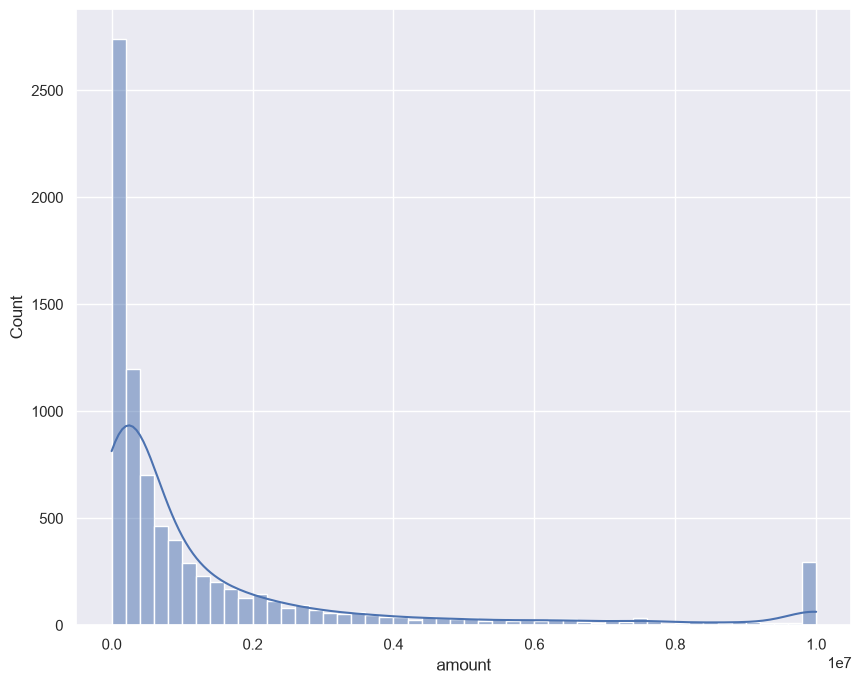

In [78]:
plt.figure(figsize = (10,8))
sns.histplot(data = frauds, x = "amount", bins = 50, kde = True)

In [79]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,Desttype,hour,Day,Day_Name,Orginal_balance_diff,Dest_balance_diff,log_amount,amount_to_orig_balance,amount_to_dest_balance
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,M,1,0,Monday,9839.64,0.0,9.194276,0.057834,9839.640000
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,M,1,0,Monday,1864.28,0.0,7.531166,0.087731,1864.280000
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,C,1,0,Monday,181.00,0.0,5.204007,0.994505,181.000000
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,C,1,0,Monday,181.00,21182.0,5.204007,0.994505,0.008545
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,M,1,0,Monday,11668.14,0.0,9.364703,0.280788,11668.140000


In [80]:
df.columns.tolist()

['step',
 'type',
 'amount',
 'nameOrig',
 'oldbalanceOrg',
 'newbalanceOrig',
 'nameDest',
 'oldbalanceDest',
 'newbalanceDest',
 'isFraud',
 'isFlaggedFraud',
 'Desttype',
 'hour',
 'Day',
 'Day_Name',
 'Orginal_balance_diff',
 'Dest_balance_diff',
 'log_amount',
 'amount_to_orig_balance',
 'amount_to_dest_balance']

In [81]:
features = [
 'type',
 'amount',
 'oldbalanceOrg',
 'newbalanceOrig',
 'oldbalanceDest',
 'newbalanceDest',
 'isFraud',
 'Desttype',
 'hour',
 'Day_Name',
 'Orginal_balance_diff',
 'Dest_balance_diff',
 'amount_to_orig_balance',
 'amount_to_dest_balance']

In [82]:
X = df[features].drop(columns="isFraud")

In [83]:
X.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,Desttype,hour,Day_Name,Orginal_balance_diff,Dest_balance_diff,amount_to_orig_balance,amount_to_dest_balance
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,M,1,Monday,9839.64,0.0,0.057834,9839.640000
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,M,1,Monday,1864.28,0.0,0.087731,1864.280000
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,C,1,Monday,181.00,0.0,0.994505,181.000000
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,C,1,Monday,181.00,21182.0,0.994505,0.008545
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,M,1,Monday,11668.14,0.0,0.280788,11668.140000


In [84]:
y=df["isFraud"]

In [85]:
y.head()

0    0
1    0
2    1
3    1
4    0
Name: isFraud, dtype: int64

In [86]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 13 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   type                    str    
 1   amount                  float64
 2   oldbalanceOrg           float64
 3   newbalanceOrig          float64
 4   oldbalanceDest          float64
 5   newbalanceDest          float64
 6   Desttype                str    
 7   hour                    int64  
 8   Day_Name                str    
 9   Orginal_balance_diff    float64
 10  Dest_balance_diff       float64
 11  amount_to_orig_balance  float64
 12  amount_to_dest_balance  float64
dtypes: float64(9), int64(1), str(3)
memory usage: 631.1 MB


In [87]:
cat_features = ["type","Desttype", "Day_Name"]
cat_features

['type', 'Desttype', 'Day_Name']

In [88]:
numerical_features = [x for x in X.columns
                      if x not in cat_features]

In [89]:
numerical_features

['amount',
 'oldbalanceOrg',
 'newbalanceOrig',
 'oldbalanceDest',
 'newbalanceDest',
 'hour',
 'Orginal_balance_diff',
 'Dest_balance_diff',
 'amount_to_orig_balance',
 'amount_to_dest_balance']

<Axes: >

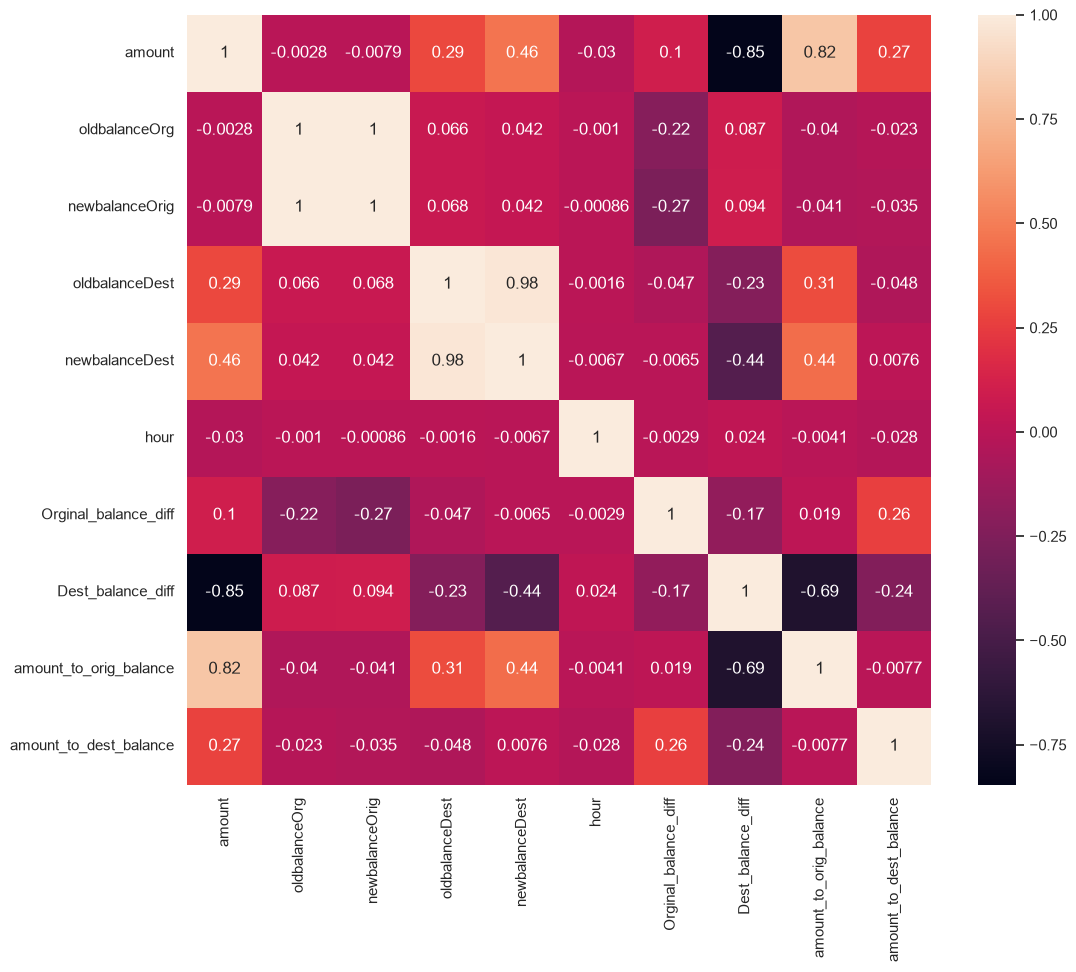

In [116]:
corr = X[numerical_features].corr()
plt.figure(figsize = (12,10))
sns.heatmap(corr, annot=True)

In [90]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier

from sklearn.naive_bayes import GaussianNB

from sklearn.pipeline import Pipeline


In [91]:
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_recall_curve,
    precision_score,
    roc_auc_score,
    f1_score,
    confusion_matrix,
    average_precision_score,
    roc_curve
)

In [92]:
from sklearn.model_selection import train_test_split

In [127]:
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42, test_size=0.25, stratify=y)

In [128]:
print(f"X_train_size = {X_train.shape[0]},\n X_test_size = {X_test.shape[0]}")

X_train_size = 4771965,
 X_test_size = 1590655


In [129]:
preprocessor = ColumnTransformer(transformers=[("num", StandardScaler(), numerical_features),
                                 ("cat", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), cat_features)])

In [130]:
#Training the Logitic Model

logistic_model = Pipeline(steps = [("preprocessor", preprocessor), ("model", LogisticRegression(max_iter=1000, solver = "lbfgs", class_weight="balanced"))])

In [131]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['type','amount','oldbalanceOrg',...,'Dest_balance_diff', 'amount_to_orig_balance','amount_to_dest_balance']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specify

In [132]:
logistic_preds = logistic_model.predict(X_test)

In [133]:
logistic_prob = logistic_model.predict_proba(X_test)[:,1]

In [136]:
print(f"Accuracy : {accuracy_score(y_test, logistic_preds)},\nPrecision Score : {precision_score(y_test, logistic_preds)},\nRecall Score : {recall_score(y_test, logistic_preds)},\nAverage Precision Score : {average_precision_score(y_test, logistic_prob)},\nF1 Score : {f1_score(y_test, logistic_preds)},\nROC_AUC_Score : {roc_auc_score(y_test, logistic_prob)}")

Accuracy : 0.9530551879571623,
Precision Score : 0.025533138197783817,
Recall Score : 0.9517778860204579,
Average Precision Score : 0.5829862953457926,
F1 Score : 0.04973212354131406,
ROC_AUC_Score : 0.991765002828819


In [137]:
from sklearn.metrics import classification_report

In [138]:
print(f"Logistic Classification Report : \n {classification_report(y_test, logistic_preds)}")

Logistic Classification Report : 
               precision    recall  f1-score   support

           0       1.00      0.95      0.98   1588602
           1       0.03      0.95      0.05      2053

    accuracy                           0.95   1590655
   macro avg       0.51      0.95      0.51   1590655
weighted avg       1.00      0.95      0.97   1590655



In [139]:
print("confusion_matrix\n", confusion_matrix(y_test, logistic_preds))

confusion_matrix
 [[1514028   74574]
 [     99    1954]]


<Axes: >

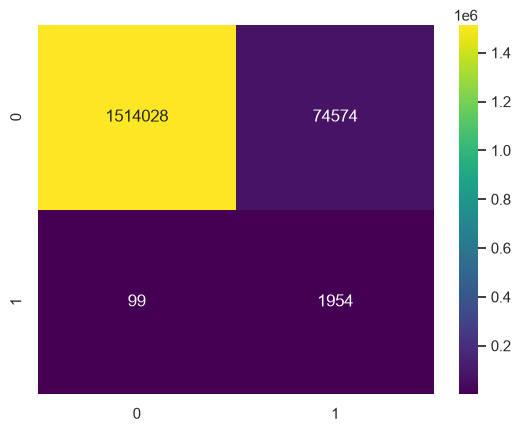

In [140]:
sns.heatmap(confusion_matrix(y_test, logistic_preds), annot=True, fmt = "d", cmap = "viridis")

In [141]:
thresholds = [0.5,0.6,0.7,0.8,0.9]

In [142]:
for t in thresholds:
    logistic_pred_threshold = (logistic_prob >= t).astype(int)

    print(t, "accuracy score:", accuracy_score(y_test, logistic_pred_threshold), "recall score :", recall_score(y_test, logistic_pred_threshold), "precision score :", precision_score(y_test, logistic_pred_threshold))

0.5 accuracy score: 0.9530551879571623 recall score : 0.9517778860204579 precision score : 0.025533138197783817
0.6 accuracy score: 0.966527625412173 recall score : 0.9332683877252801 precision score : 0.03482243466249864
0.7 accuracy score: 0.9764801292549296 recall score : 0.9025815879201169 precision score : 0.0474337642390887
0.8 accuracy score: 0.9844366000169742 recall score : 0.8567949342425718 precision score : 0.06708363525418558
0.9 accuracy score: 0.99105777179841 recall score : 0.7978567949342426 precision score : 0.10604000776849874


In [143]:
#TRAINING THE DECISION TREE MODEL

dt_model = Pipeline(steps = [("preprocessor", preprocessor), ("model", DecisionTreeClassifier(max_depth=10, min_samples_split = 10, min_samples_leaf=5, class_weight="balanced", random_state=42))])

In [144]:
dt_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['type','amount','oldbalanceOrg',...,'Dest_balance_diff', 'amount_to_orig_balance','amount_to_dest_balance']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specify

In [145]:
dt_preds = dt_model.predict(X_test)

In [146]:
dt_probs = dt_model.predict_proba(X_test)[:,1]

In [147]:
print(f"Accuracy : {accuracy_score(y_test, dt_preds)},\nPrecision Score : {precision_score(y_test, dt_preds)},\nRecall Score : {recall_score(y_test, dt_preds)},\nAverage Precision Score : {average_precision_score(y_test, dt_probs)},\nF1 Score : {f1_score(y_test, dt_preds)},\nROC_AUC_Score : {roc_auc_score(y_test, dt_probs)}")

Accuracy : 0.9923930707790187,
Precision Score : 0.14390019139434324,
Recall Score : 0.9887968826108134,
Average Precision Score : 0.7125574281821582,
F1 Score : 0.25123762376237624,
ROC_AUC_Score : 0.9928779879286598


In [154]:
print(f"Classification DT Report : \n {classification_report(y_test, dt_preds)}")

Classification DT Report : 
               precision    recall  f1-score   support

           0       1.00      0.99      1.00   1588602
           1       0.14      0.99      0.25      2053

    accuracy                           0.99   1590655
   macro avg       0.57      0.99      0.62   1590655
weighted avg       1.00      0.99      1.00   1590655



In [155]:
print("confusion_matrix\n", confusion_matrix(y_test, dt_preds))

confusion_matrix
 [[1576525   12077]
 [     23    2030]]


In [156]:
#Hyperparameter Tuning of Decision Tree

from sklearn.model_selection import GridSearchCV

dt_model_tuned = Pipeline(steps = [("preprocessor", preprocessor), ("model", DecisionTreeClassifier(class_weight="balanced", random_state=42))])


param_grid = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [5, 10, 15, 20, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 5, 10],
    "model__max_features": ["sqrt", "log2", None]
}

grid = GridSearchCV(estimator=dt_model_tuned, param_grid=param_grid, cv = 3, scoring="f1", n_jobs=-1, verbose=1)

In [157]:
grid.fit(X_train, y_train)

Fitting 3 folds for each of 270 candidates, totalling 810 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__criterion': ['gini', 'entropy'], 'model__max_depth': [5, 10, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': [1, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metr

In [158]:
print(grid.best_params_)
print(grid.best_score_)

{'model__criterion': 'entropy', 'model__max_depth': None, 'model__max_features': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
0.8802005420807574


In [159]:
#TRAINING THE RANDOM FOREST MODEL

In [182]:
rf_model = Pipeline(steps = [("preprocessor", preprocessor), ("model", RandomForestClassifier(n_estimators=100, max_depth = 5, n_jobs=-1, random_state=42, class_weight="balanced", min_samples_split=5))])

In [183]:
rf_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['type','amount','oldbalanceOrg',...,'Dest_balance_diff', 'amount_to_orig_balance','amount_to_dest_balance']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specify

In [184]:
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:,1]

In [185]:
print(f"Accuracy : {accuracy_score(y_test, rf_preds)},\nPrecision Score : {precision_score(y_test, rf_preds)},\nRecall Score : {recall_score(y_test, rf_preds)},\nAverage Precision Score : {average_precision_score(y_test, rf_probs)},\nF1 Score : {f1_score(y_test, rf_preds)},\nROC_AUC_Score : {roc_auc_score(y_test, rf_probs)}")

Accuracy : 0.962978144223606,
Precision Score : 0.03295204286230812,
Recall Score : 0.976619581100828,
Average Precision Score : 0.7899749701205805,
F1 Score : 0.06375300084262071,
ROC_AUC_Score : 0.9963385158692035


In [186]:
print(f"Classification RF Report : \n {classification_report(y_test, rf_preds)}")

Classification RF Report : 
               precision    recall  f1-score   support

           0       1.00      0.96      0.98   1588602
           1       0.03      0.98      0.06      2053

    accuracy                           0.96   1590655
   macro avg       0.52      0.97      0.52   1590655
weighted avg       1.00      0.96      0.98   1590655



In [187]:
print("confusion_matrix\n", confusion_matrix(y_test, rf_preds))

confusion_matrix
 [[1529761   58841]
 [     48    2005]]


In [188]:
#GRADIENT BOOSTING MODEL TRAINING

In [189]:
GradientBoostingClassifier?


Init signature:
GradientBoostingClassifier(
    *,
    loss='log_loss',
    learning_rate=0.1,
    n_estimators=100,
    subsample=1.0,
    criterion='deprecated',
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_depth=3,
    min_impurity_decrease=0.0,
    init=None,
    random_state=None,
    max_features=None,
    verbose=0,
    max_leaf_nodes=None,
    warm_start=False,
    validation_fraction=0.1,
    n_iter_no_change=None,
    tol=0.0001,
    ccp_alpha=0.0,
)
Docstring:     
Gradient Boosting for classification.

This algorithm builds an additive model in a forward stage-wise fashion; it
allows for the optimization of arbitrary differentiable loss functions. In
each stage ``n_classes_`` regression trees are fit on the negative gradient
of the loss function, e.g. binary or multiclass log loss. Binary
classification is a special case where only a single regression tree is
induced.

:class:`~sklearn.ensemble.HistGradientBoostingClassifier` is

In [190]:
gb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingClassifier(
                n_estimators=100,
                learning_rate=0.1,
                max_depth=5,
                min_samples_split=5,
                random_state=42
            )
        )
    ]
)

In [191]:
gb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['type','amount','oldbalanceOrg',...,'Dest_balance_diff', 'amount_to_orig_balance','amount_to_dest_balance']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specify

In [192]:
gb_preds = gb_model.predict(X_test)
gb_probs = gb_model.predict_proba(X_test)[:,1]

In [193]:
print(f"Accuracy : {accuracy_score(y_test, gb_preds)},\nPrecision Score : {precision_score(y_test, gb_preds)},\nRecall Score : {recall_score(y_test, gb_preds)},\nAverage Precision Score : {average_precision_score(y_test, gb_probs)},\nF1 Score : {f1_score(y_test, gb_preds)},\nROC_AUC_Score : {roc_auc_score(y_test, gb_probs)}")

Accuracy : 0.99935812605499,
Precision Score : 0.9121405750798722,
Recall Score : 0.5562591329761325,
Average Precision Score : 0.6415237936057808,
F1 Score : 0.6910741301059001,
ROC_AUC_Score : 0.8456019698554563


In [194]:
print(f"Classification GB Report : \n {classification_report(y_test, gb_preds)}")

Classification GB Report : 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00   1588602
           1       0.91      0.56      0.69      2053

    accuracy                           1.00   1590655
   macro avg       0.96      0.78      0.85   1590655
weighted avg       1.00      1.00      1.00   1590655



In [195]:
print("confusion_matrix\n", confusion_matrix(y_test, gb_preds))

confusion_matrix
 [[1588492     110]
 [    911    1142]]


In [196]:
#EXTRA TREES MODEL TRAINING

xt_model = Pipeline(steps = [("preprocessor", preprocessor), ("model", ExtraTreesClassifier(n_estimators = 100, max_depth = 10, class_weight="balanced", n_jobs = -1, random_state=42))])

In [198]:
xt_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['type','amount','oldbalanceOrg',...,'Dest_balance_diff', 'amount_to_orig_balance','amount_to_dest_balance']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specify

In [199]:
xt_preds = xt_model.predict(X_test)
xt_probs = xt_model.predict_proba(X_test)[:,1]

In [200]:
print(f"Accuracy : {accuracy_score(y_test, xt_preds)},\nPrecision Score : {precision_score(y_test, xt_preds)},\nRecall Score : {recall_score(y_test,xt_preds)},\nAverage Precision Score : {average_precision_score(y_test, xt_probs)},\nF1 Score : {f1_score(y_test, xt_preds)},\nROC_AUC_Score : {roc_auc_score(y_test, xt_probs)}")

Accuracy : 0.8681103067604226,
Precision Score : 0.008926123093506813,
Recall Score : 0.9196298100340965,
Average Precision Score : 0.4659703240758309,
F1 Score : 0.01768063418037431,
ROC_AUC_Score : 0.9676291134044082


In [201]:
print(f"Classification Extra Trees Report : \n {classification_report(y_test, xt_preds)}")

Classification Extra Trees Report : 
               precision    recall  f1-score   support

           0       1.00      0.87      0.93   1588602
           1       0.01      0.92      0.02      2053

    accuracy                           0.87   1590655
   macro avg       0.50      0.89      0.47   1590655
weighted avg       1.00      0.87      0.93   1590655



In [202]:
print("confusion_matrix\n", confusion_matrix(y_test, xt_preds))

confusion_matrix
 [[1378976  209626]
 [    165    1888]]


In [203]:
nb_model = Pipeline([("preprocessor", preprocessor), ("model", GaussianNB())])

In [205]:
nb_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['type','amount','oldbalanceOrg',...,'Dest_balance_diff', 'amount_to_orig_balance','amount_to_dest_balance']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specify

In [206]:
nb_preds = nb_model.predict(X_test)
nb_probs = nb_model.predict_proba(X_test)[:,1]

In [207]:
print(f"Accuracy : {accuracy_score(y_test, nb_preds)},\nPrecision Score : {precision_score(y_test, nb_preds)},\nRecall Score : {recall_score(y_test,nb_preds)},\nAverage Precision Score : {average_precision_score(y_test, nb_probs)},\nF1 Score : {f1_score(y_test, nb_preds)},\nROC_AUC_Score : {roc_auc_score(y_test, nb_probs)}")

Accuracy : 0.6171916600394177,
Precision Score : 0.0033602359530516277,
Recall Score : 1.0,
Average Precision Score : 0.009070492204525363,
F1 Score : 0.006697965162751092,
ROC_AUC_Score : 0.9274580029070499


In [208]:
print(f"Classification NB Report : \n {classification_report(y_test, nb_preds)}")

Classification NB Report : 
               precision    recall  f1-score   support

           0       1.00      0.62      0.76   1588602
           1       0.00      1.00      0.01      2053

    accuracy                           0.62   1590655
   macro avg       0.50      0.81      0.38   1590655
weighted avg       1.00      0.62      0.76   1590655



In [209]:
print("confusion_matrix\n", confusion_matrix(y_test, nb_preds))

confusion_matrix
 [[979686 608916]
 [     0   2053]]


In [ ]:
def model_evaluation(model_name, test, pred, prob):

    accuracy = accuracy_score(test, pred)

    precision = precision_score(test, pred)

    pr_auc = average_precision_score(test, prob)

    f1 = f1_score(test, pred)

    recall = recall_score(test, pred)

    roc_auc = roc_auc_score(test, prob)

    return {

        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc

    }

In [211]:
print(model_evaluation("Logistic Regression", y_test, logistic_preds, logistic_prob))

{'Model': 'Logistic Regression', 'Accuracy': 0.9530551879571623, 'Precision': 0.025533138197783817, 'Recall': 0.9517778860204579, 'F1 Score': 0.04973212354131406, 'ROC-AUC': 0.991765002828819, 'PR-AUC': 0.5829862953457926}


In [213]:
results = []

In [216]:
results.append(model_evaluation("Logistic Regression", y_test, logistic_preds, logistic_prob))

In [218]:
results.append(model_evaluation("Random Forest Classifier", y_test, rf_preds, rf_probs))

In [219]:
results.append(model_evaluation("Decision Tree Classifier", y_test, dt_preds, dt_probs))

In [220]:
results.append(model_evaluation("Gradient Boost Classifier", y_test, gb_preds, gb_probs))

In [221]:
results.append(model_evaluation("Extra Tree Classifier", y_test, xt_preds, xt_probs))

In [222]:
results.append(model_evaluation("Naive Bayes Classifier", y_test, nb_preds, nb_probs))

In [223]:
print(results)

[{'Model': 'Logistic Regression', 'Accuracy': 0.9530551879571623, 'Precision': 0.025533138197783817, 'Recall': 0.9517778860204579, 'F1 Score': 0.04973212354131406, 'ROC-AUC': 0.991765002828819, 'PR-AUC': 0.5829862953457926}, {'Model': 'Random Forest Classifier', 'Accuracy': 0.962978144223606, 'Precision': 0.03295204286230812, 'Recall': 0.976619581100828, 'F1 Score': 0.06375300084262071, 'ROC-AUC': 0.9963385158692035, 'PR-AUC': 0.7899749701205805}, {'Model': 'Decision Tree Classifier', 'Accuracy': 0.9923930707790187, 'Precision': 0.14390019139434324, 'Recall': 0.9887968826108134, 'F1 Score': 0.25123762376237624, 'ROC-AUC': 0.9928779879286598, 'PR-AUC': 0.7125574281821582}, {'Model': 'Gradient Boost Classifier', 'Accuracy': 0.99935812605499, 'Precision': 0.9121405750798722, 'Recall': 0.5562591329761325, 'F1 Score': 0.6910741301059001, 'ROC-AUC': 0.8456019698554563, 'PR-AUC': 0.6415237936057808}, {'Model': 'Extra Tree Classifier', 'Accuracy': 0.8681103067604226, 'Precision': 0.00892612309

In [224]:
results_df = pd.DataFrame(results)

In [225]:
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.953055,0.025533,0.951778,0.049732,0.991765,0.582986
1,Random Forest Classifier,0.962978,0.032952,0.976620,0.063753,0.996339,0.789975
2,Decision Tree Classifier,0.992393,0.143900,0.988797,0.251238,0.992878,0.712557
3,Gradient Boost Classifier,0.999358,0.912141,0.556259,0.691074,0.845602,0.641524
4,Extra Tree Classifier,0.868110,0.008926,0.919630,0.017681,0.967629,0.465970
5,Naive Bayes Classifier,0.617192,0.003360,1.000000,0.006698,0.927458,0.009070


Gradient Boost is overall the best model as its precision 91%. Therefore it catches frauds very well. But the recall score is low, so we have to trade off some legitimate customers as frauds. 
So this will be our first model to fine tune.

Other model would be Decision Tree Model and Random forest model


In [241]:
gb = Pipeline(steps = [("preprocessor", preprocessor), ("model", GradientBoostingClassifier(random_state = 42))])

param_grid = {
    "model__n_estimators": [50, 100],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3],
    "model__min_samples_split": [5, 10],
    "model__min_samples_leaf": [2, 5]
}

grid_gb = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv=3,
    scoring = {
        "f1": "f1",
        "recall": "recall",
        "precision": "precision"
    },
    refit="f1",
    n_jobs=-1,
    verbose=2
)

In [242]:
grid_gb.fit(X_train,y_train)

Fitting 3 folds for each of 32 candidates, totalling 96 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.05, 0.1], 'model__max_depth': [2, 3], 'model__min_samples_leaf': [2, 5], 'model__min_samples_split': [5, 10], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'f1': 'f1', 'precision': 'precision', 'recall': 'recall'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0

In [243]:
print("Best Parameters:")
print(grid_gb.best_params_)

print("Best CV F1:")
print(grid_gb.best_score_)

Best Parameters:
{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_samples_leaf': 5, 'model__min_samples_split': 5, 'model__n_estimators': 100}
Best CV F1:
0.5909402701983332


In [244]:
# Tuning the Decision tree model

In [245]:
#Hyperparameter Tuning of Decision Tree

from sklearn.model_selection import GridSearchCV

dt_model_tuned = Pipeline(steps = [("preprocessor", preprocessor), ("model", DecisionTreeClassifier(class_weight="balanced", random_state=42))])


param_grid = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [5, 10, 15, 20, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 5, 10],
    "model__max_features": ["sqrt", "log2", None]
}

grid_dt = GridSearchCV(estimator=dt_model_tuned, param_grid=param_grid, cv = 3, scoring="f1", n_jobs=-1, verbose=1)

In [246]:
grid_dt.fit(X_train,y_train)

Fitting 3 folds for each of 270 candidates, totalling 810 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__criterion': ['gini', 'entropy'], 'model__max_depth': [5, 10, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': [1, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metr

In [247]:
print(grid_dt.best_params_)
print(grid_dt.best_score_)

{'model__criterion': 'entropy', 'model__max_depth': None, 'model__max_features': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
0.8802005420807574


In [248]:
#Fine Tuning the RF Model

rf_model_tuned = Pipeline(steps = [("preprocessor", preprocessor), ("model", RandomForestClassifier(class_weight="balanced", n_jobs=-1, random_state=42))])

param_grid_rf = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 20, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", "log2"]
}

grid_rf = GridSearchCV(estimator=rf_model_tuned, param_grid=param_grid_rf, cv=3, scoring = "f1", n_jobs=-1, verbose = 2)

grid_rf.fit(X_train, y_train)

Fitting 3 folds for each of 48 candidates, totalling 144 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [10, 20, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.S

In [249]:
print("Best Parameters:")
print(grid_rf.best_params_)

print("Best CV F1:")
print(grid_rf.best_score_)

Best Parameters:
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV F1:
0.8964790825618896


In [265]:
#ROC Curve for all the selected models
from sklearn.metrics import roc_curve, roc_auc_score

models = {
    "Gradient Boosting" : gb_probs,
    "Decision Tree Model" : dt_probs,
    "Random Forest Model" : rf_probs
}

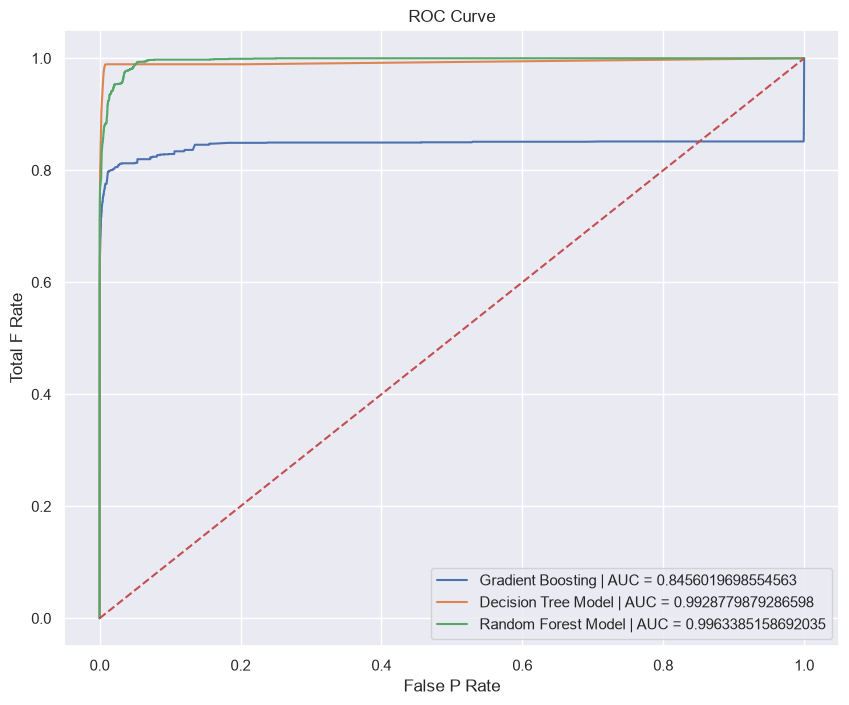

In [266]:
plt.figure(figsize=(10,8))

for name, prob in models.items():

    fpr, tpr, threshold = roc_curve(y_test, prob)

    AUC_Score = roc_auc_score(y_test, prob)

    plt.plot(fpr, tpr, label = f"{name} | AUC = {AUC_Score}")

plt.plot([0,1], [0,1], linestyle = "--")

plt.xlabel("False P Rate")
plt.ylabel("Total F Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

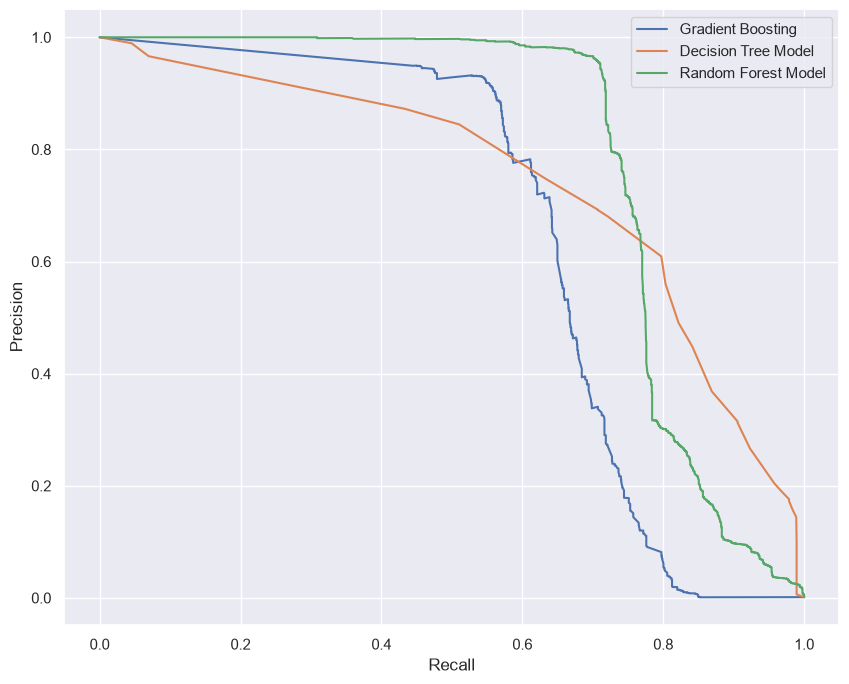

In [268]:
#Precision Recall Curves

from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(10,8))

for name, prob in models.items():

    precision, recall, threshold = precision_recall_curve(y_test, prob)

    plt.plot(recall, precision, label = f"{name}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

Confusion Matrix Gradient Boosting : 
 [[1588492     110]
 [    911    1142]]


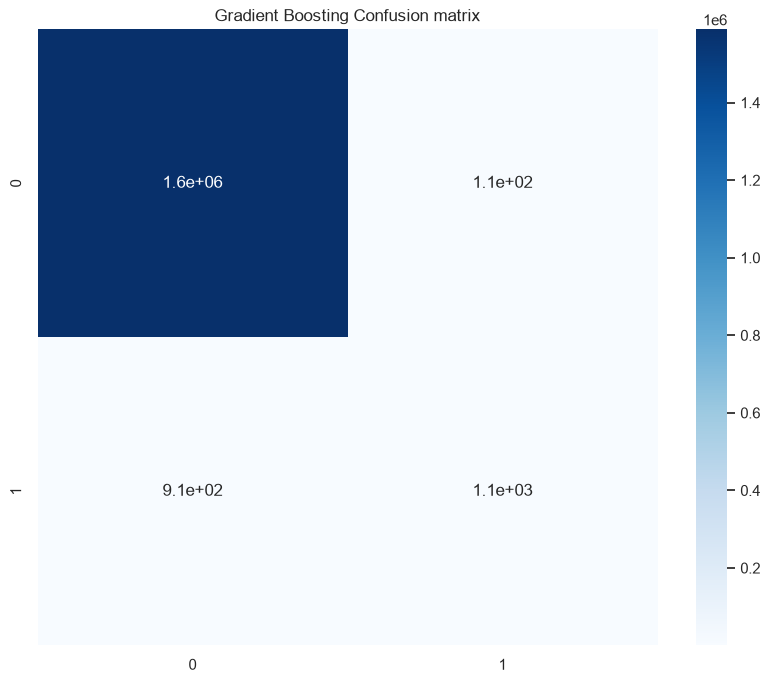

Confusion Matrix Decision Tree Model : 
 [[1576525   12077]
 [     23    2030]]


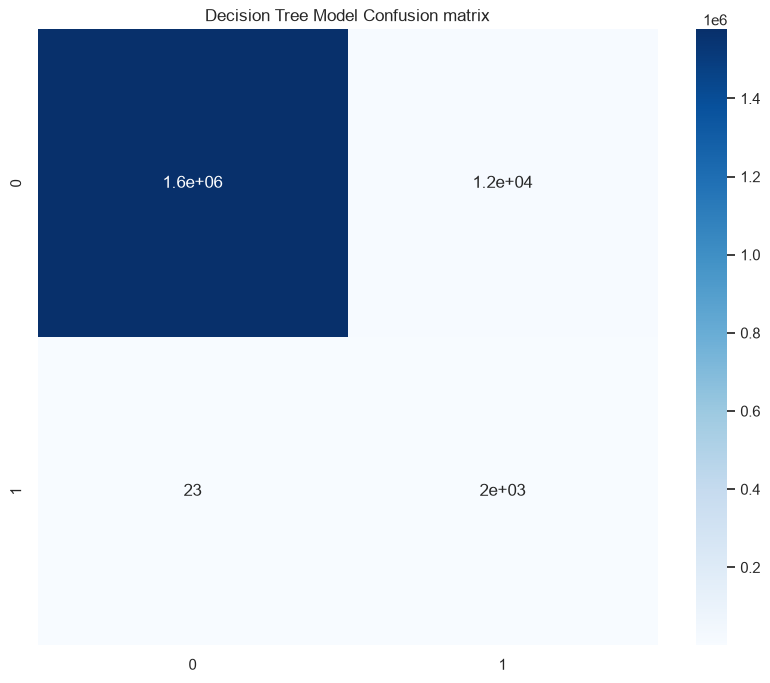

Confusion Matrix Random Forest Model : 
 [[1529761   58841]
 [     48    2005]]


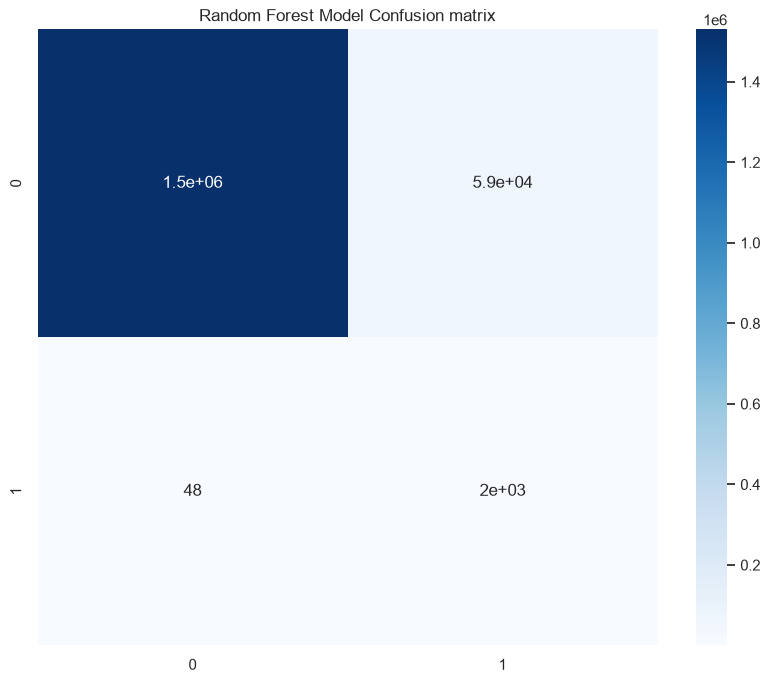

In [271]:
models = {
    "Gradient Boosting" : gb_preds,
    "Decision Tree Model" : dt_preds,
    "Random Forest Model" : rf_preds
}

for model, pred in models.items():

    conf_matrix = confusion_matrix(y_test, pred)

    print(f"Confusion Matrix {model} : \n {conf_matrix}")

    plt.figure(figsize=(10,8))
    sns.heatmap(conf_matrix, annot = True, cmap = "Blues")
    plt.title(f"{model} Confusion matrix")
    plt.show()

Based on the different scores and the curves of the following three methods, Random Forest performs the best in this segment by giving a presicion of 88% without sacrificing the recall value.

__________________________________________________________________________________________

__________________________________________________________________________________________

_____________________________________________________________________________________

In [273]:
final_rf_model = Pipeline(steps=[("preprocessor", preprocessor),
                                ("model", RandomForestClassifier(class_weight="balanced", n_estimators = 200, max_features = "sqrt", min_samples_leaf = 1, max_depth = None, min_samples_split = 2))])

In [274]:
final_rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['type','amount','oldbalanceOrg',...,'Dest_balance_diff', 'amount_to_orig_balance','amount_to_dest_balance']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specify

In [275]:
final_rf_preds = final_rf_model.predict(X_test)
final_rf_probs = final_rf_model.predict_proba(X_test)[:,1]

In [276]:
print("Random Forest Final Results \n")
print(f"Accuracy : {accuracy_score(y_test, final_rf_preds)},\nPrecision Score : {precision_score(y_test, final_rf_preds)},\nRecall Score : {recall_score(y_test, final_rf_preds)},\nAverage Precision Score : {average_precision_score(y_test, final_rf_probs)},\nF1 Score : {f1_score(y_test, final_rf_preds)},\nROC_AUC_Score : {roc_auc_score(y_test, final_rf_probs)}")

Random Forest Final Results 

Accuracy : 0.9997541893119501,
Precision Score : 0.9496753246753247,
Recall Score : 0.8548465660009742,
Average Precision Score : 0.9534972944123002,
F1 Score : 0.8997692899256601,
ROC_AUC_Score : 0.9988786758430721


In [277]:
print(f"Classification Random Forest Report : \n {classification_report(y_test, final_rf_preds)}")

Classification Random Forest Report : 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00   1588602
           1       0.95      0.85      0.90      2053

    accuracy                           1.00   1590655
   macro avg       0.97      0.93      0.95   1590655
weighted avg       1.00      1.00      1.00   1590655



confusion_matrix
 [[1588509      93]
 [    298    1755]]


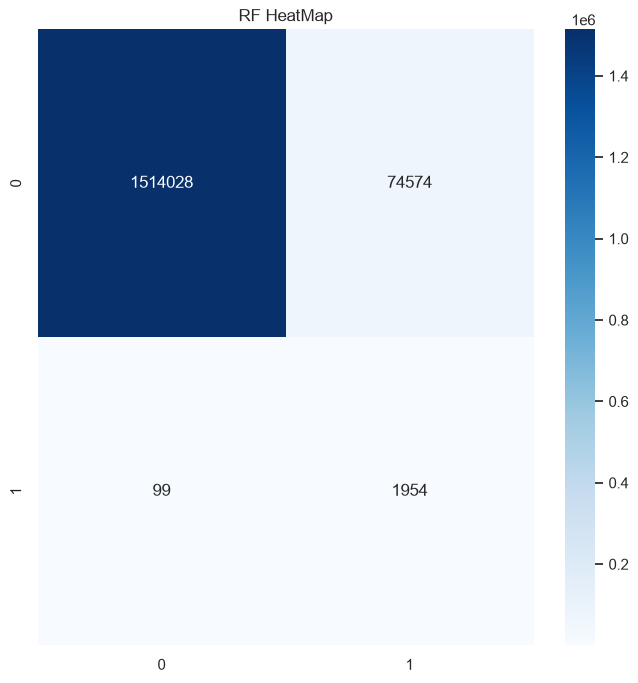

In [278]:
print("confusion_matrix\n", confusion_matrix(y_test, final_rf_preds))

plt.figure(figsize=(8,8))
sns.heatmap(confusion_matrix(y_test, logistic_preds), annot=True, fmt = "d", cmap = "Blues")
plt.title("RF HeatMap")
plt.show()

C:\Users\Piyush\AppData\Local\Temp\ipykernel_29540\3103723280.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


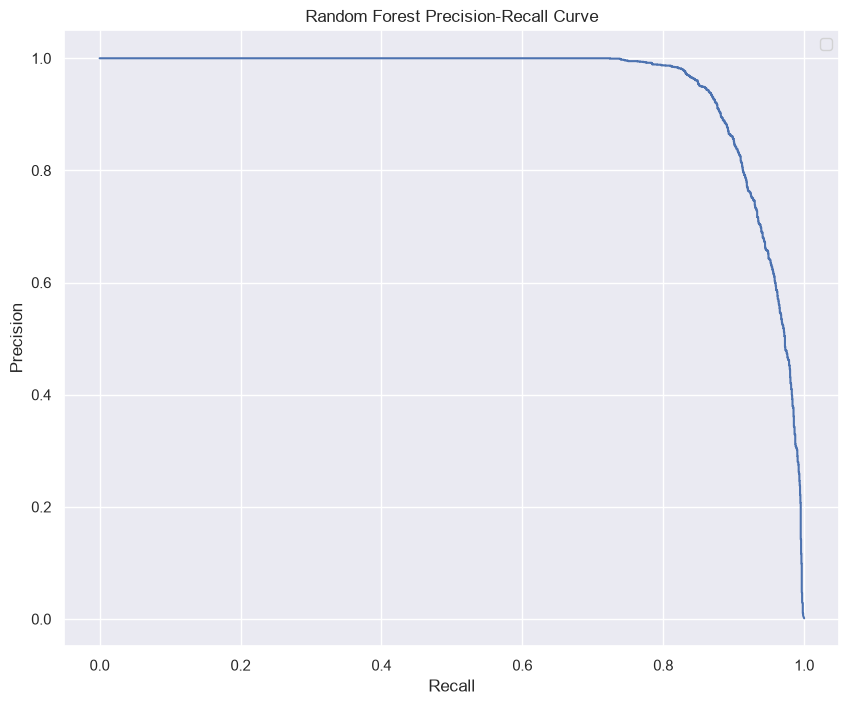

In [279]:
plt.figure(figsize=(10,8))

precision, recall, threshold = precision_recall_curve(y_test, final_rf_probs)

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Random Forest Precision-Recall Curve")
plt.legend()
plt.show()

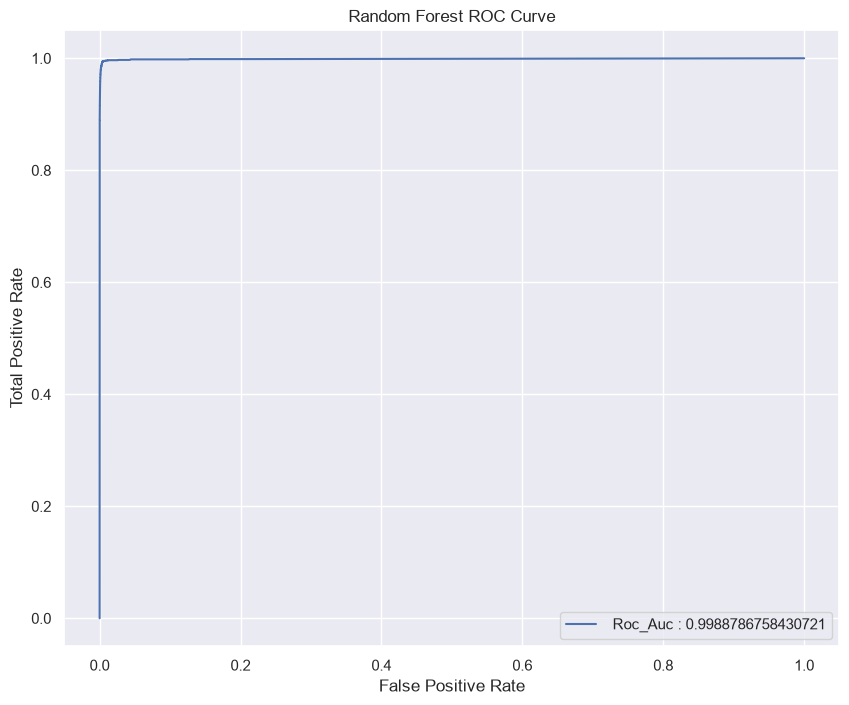

In [280]:
plt.figure(figsize=(10,8))

fpr, tpr, threshold = roc_curve(y_test, final_rf_probs)

plt.plot(fpr, tpr, label = f" Roc_Auc : {roc_auc_score(y_test, final_rf_probs)}")

plt.xlabel("False Positive Rate")
plt.ylabel("Total Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()
plt.show()

In [283]:
#Features and their importances

rf_preprocessor =final_rf_model.named_steps["preprocessor"]

In [284]:
rf_features_names = rf_preprocessor.get_feature_names_out()

In [285]:
rf_classifier = final_rf_model.named_steps["model"]

rf_importances = rf_classifier.feature_importances_

In [286]:
rf_features_importance = {"Features" : rf_features_names,
                          "Importance" : rf_importances}

In [290]:
Importance_df = pd.DataFrame(rf_features_importance)

In [293]:
Importance_df.sort_values("Importance", ascending = False).reset_index().drop(columns = "index")

,Features,Importance
0,num__Orginal_balance_diff,0.248586
1,num__oldbalanceOrg,0.132689
2,num__amount,0.091093
3,num__newbalanceOrig,0.086440
4,num__amount_to_dest_balance,0.073575
5,num__Dest_balance_diff,0.062313
6,num__amount_to_orig_balance,0.058012
7,cat__type_TRANSFER,0.042512
8,cat__Desttype_C,0.032445
9,num__hour,0.030171


In [281]:
#Final fine Tuning the model by threshold values

In [298]:
thresholds = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]

threshold_results = []

for threshold in thresholds:

    final_rf_preds_threshold = (final_rf_probs >= threshold).astype(int)
    threshold_results.append({"Threshold" : threshold, "Recall" : recall_score(y_test, final_rf_preds_threshold), "Precision" : precision_score(y_test, final_rf_preds_threshold), "F1 Score" : f1_score(y_test, final_rf_preds_threshold)})
    print(f"Confusion Matrix \n: {confusion_matrix(y_test, final_rf_preds_threshold)}\n")

Confusion Matrix 
: [[1584257    4345]
 [     26    2027]]

Confusion Matrix 
: [[1587287    1315]
 [     84    1969]]

Confusion Matrix 
: [[1588059     543]
 [    167    1886]]

Confusion Matrix 
: [[1588368     234]
 [    232    1821]]

Confusion Matrix 
: [[1588509      93]
 [    298    1755]]

Confusion Matrix 
: [[1588558      44]
 [    346    1707]]

Confusion Matrix 
: [[1588576      26]
 [    383    1670]]

Confusion Matrix 
: [[1588584      18]
 [    440    1613]]

Confusion Matrix 
: [[1588601       1]
 [    555    1498]]



In [299]:
threshold_results

[{'Threshold': 0.1,
  'Recall': 0.9873356064296152,
  'Precision': 0.31811048336472064,
  'F1 Score': 0.48118694362017805},
 {'Threshold': 0.2,
  'Recall': 0.9590842669264491,
  'Precision': 0.5995736906211937,
  'F1 Score': 0.7378677159452877},
 {'Threshold': 0.3,
  'Recall': 0.9186556259132976,
  'Precision': 0.7764512144915603,
  'F1 Score': 0.8415885765283355},
 {'Threshold': 0.4,
  'Recall': 0.8869946419873356,
  'Precision': 0.8861313868613139,
  'F1 Score': 0.8865628042843233},
 {'Threshold': 0.5,
  'Recall': 0.8548465660009742,
  'Precision': 0.9496753246753247,
  'F1 Score': 0.8997692899256601},
 {'Threshold': 0.6,
  'Recall': 0.8314661471018022,
  'Precision': 0.9748715019988577,
  'F1 Score': 0.8974763406940063},
 {'Threshold': 0.7,
  'Recall': 0.8134437408670239,
  'Precision': 0.9846698113207547,
  'F1 Score': 0.8909042411309682},
 {'Threshold': 0.8,
  'Recall': 0.7856794934242571,
  'Precision': 0.9889638258736971,
  'F1 Score': 0.8756786102062974},
 {'Threshold': 0.9,
  

In [302]:
threshold_df = pd.DataFrame(threshold_results)

In [303]:
threshold_df

,Threshold,Recall,Precision,F1 Score
0,0.1,0.987336,0.318110,0.481187
1,0.2,0.959084,0.599574,0.737868
2,0.3,0.918656,0.776451,0.841589
3,0.4,0.886995,0.886131,0.886563
4,0.5,0.854847,0.949675,0.899769
5,0.6,0.831466,0.974872,0.897476
6,0.7,0.813444,0.984670,0.890904
7,0.8,0.785679,0.988964,0.875679
8,0.9,0.729664,0.999333,0.843468


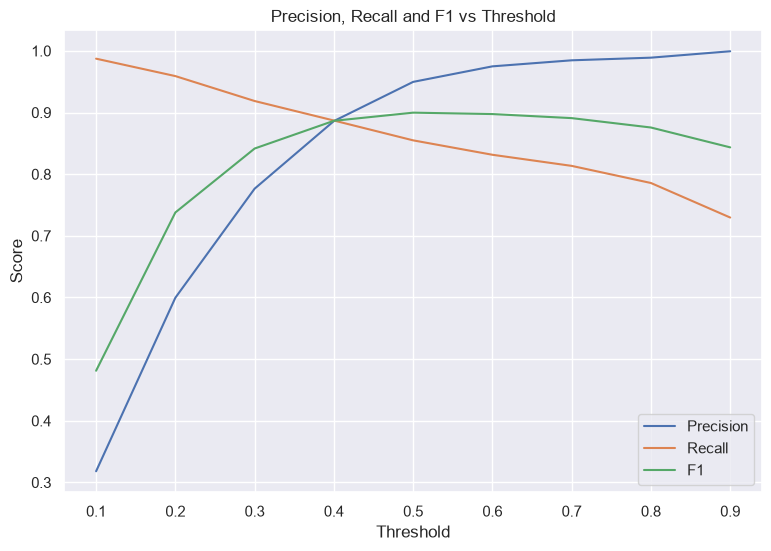

In [305]:
plt.figure(figsize=(9,6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1 Score"],
    label="F1"

)

plt.xlabel("Threshold")
plt.ylabel("Score")

plt.title(
    "Precision, Recall and F1 vs Threshold"
)

plt.legend()

plt.show()

In [306]:
import joblib

In [307]:
joblib.dump(preprocessor, "preprocessor.pkl")

['preprocessor.pkl']

In [308]:
joblib.dump(final_rf_model, "rf_model.pkl")


['rf_model.pkl']

In [ ]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 13 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   type                    str    
 1   amount                  float64
 2   oldbalanceOrg           float64
 3   newbalanceOrig          float64
 4   oldbalanceDest          float64
 5   newbalanceDest          float64
 6   Desttype                str    
 7   hour                    int64  
 8   Day_Name                str    
 9   Orginal_balance_diff    float64
 10  Dest_balance_diff       float64
 11  amount_to_orig_balance  float64
 12  amount_to_dest_balance  float64
dtypes: float64(9), int64(1), str(3)
memory usage: 631.1 MB


In [310]:
loaded_preprocessor = joblib.load("preprocessor.pkl")

In [312]:
loaded_model = joblib.load("rf_model.pkl")

In [318]:
new_transaction = pd.DataFrame({"type": ["TRANSFER"],
    "amount": [500000],
    "oldbalanceOrg": [500000],
    "newbalanceOrig": [0],
    "oldbalanceDest": [10000],
    "newbalanceDest": [10000],
    "Desttype":["M"],
    "hour": [8],
    "Day_Name": ["Tuesday"],

    "Orginal_balance_diff": [500000],
    "Dest_balance_diff": [0],

    "amount_to_orig_balance": [0.9999],
    "amount_to_dest_balance": [49.99]})

In [319]:
prediction = loaded_model.predict(
    new_transaction
)

probability = loaded_model.predict_proba(
    new_transaction
)[:, 1]

In [320]:
print("Prediction:", prediction)
print("Fraud Probability:", probability)

Prediction: [0]
Fraud Probability: [0.21]


In [321]:
if prediction[0] == 1:
    print("⚠️ Fraudulent Transaction")
else:
    print("✅ Normal Transaction")

✅ Normal Transaction
